# Sewage tracer in the Greenport area (coarse D-Flow FM model)

Four-panel map of the D-Flow FM sewage source/sink tracer (`mesh2d_sewage`, kg m$^{-3}$) at 15 days, 1 month, 2 months, and 3 months of simulated time. Each panel shows the tracer field, the D-Flow FM model grid, the Greenport MODFLOW model area, the storm-sewer outfall location, and a USGS topographic basemap.

The source/sink is placed at the Greenport storm-sewer outfall on the east side of the village (SWMM detailed-model node 171, `swmm/gp/gis/gp_junctions.shp`; 41.1046 N, 72.3592 W = UTM 18N 721754, 4553726).

> **Note.** For this demonstration the sewer discharge onset was shifted to the start of the simulation (2010-01-01) so the plume develops across the full 3-month period; the delivered/committed forcing turns the discharge on ~2010-03-01.

In [1]:
%matplotlib inline
import datetime
import numpy as np
import pathlib as pl
import sys

import geopandas as gpd
import xugrid

import matplotlib as mpl
import matplotlib.pyplot as plt

import flopy.plot.styles as styles

In [2]:
sys.path.append("../common")
from liss_settings import (
    cx, cx_provider,
    set_title_string,
    fig_ext, transparent,
)

#### Configuration

In [3]:
# D-Flow FM grid CRS (WGS84 / UTM zone 18N)
dflow_crs = 32618

# coarse GP model map output
map_path = pl.Path("../dflow-fm/coarse/tides_atm_surge/output/FlowFM_map.nc")

# Greenport MODFLOW model area (per-cell polygons; dissolved below)
gp_area_path = pl.Path("../modflow/gis/gp/gp_onshore_offshore_utm18n.shp")

tracer_var = "mesh2d_sewage"        # D-Flow FM sewage tracer concentration (kg/m3)
target_days = [15, 30, 60, 90]       # ~15 days, 1 month, 2 months, 3 months
panel_labels = ["15 days", "1 month", "2 months", "3 months"]
conc_mask = 1.0e-3                    # hide cells with tracer <= this (kg/m3)

# storm sewer outfall = SWMM detailed-model node 171 (swmm/gp/gis/gp_junctions.shp),
# east side of Greenport village; matches the [SourceSink] coordinates.
src_xy = (721753.58, 4553725.98)      # UTM 18N (E, N)
src_label = "storm sewer outfall (SWMM node 171)"
# coarse model source is nudged to the nearest always-wet cell (the 2-km coarse
# cell at the outfall is intertidal); midres/highres use the outfall point itself.
coarse_src_xy = (721859.40, 4555089.60)
coarse_src_label = "coarse source cell (nudged to wet cell)"

figsize = (9.5, 8.5)
cmap = "turbo"
basemap_kwds = {"attribution": False, "source": cx_provider, "zoom": 11}
fig_ws = pl.Path("figures")
fig_ws.mkdir(exist_ok=True, parents=True)

#### Open the coarse D-Flow FM map output

In [4]:
ds = xugrid.open_dataset(map_path)
times = ds["time"].values
print(f"{times[0]}  ->  {times[-1]}   (n={times.size})")
print(f"has {tracer_var}: {tracer_var in ds}")

2010-01-01T12:00:00.000000000  ->  2010-03-31T12:00:00.000000000   (n=90)
has mesh2d_sewage: True


#### Model grid as a GeoDataFrame (for the grid outline)

In [5]:
grid_gdf = ds["mesh2d_nFaces"].ugrid.to_geodataframe(name="cell").set_crs(dflow_crs)
grid_gdf.total_bounds

array([ 550977.38737266, 4398277.07723062,  808446.34657126,
       4591609.90357035])

#### Pick the four output times closest to the target days

In [6]:
t0 = times[0]
elapsed_days = (times - t0) / np.timedelta64(1, "D")
time_index = [int(np.argmin(np.abs(elapsed_days - d))) for d in target_days]
for lbl, d, k in zip(panel_labels, target_days, time_index):
    print(f"{lbl:>9s} (~{d:>2d} d): idx {k:4d}  ->  {times[k]}  ({elapsed_days[k]:.1f} d)")

  15 days (~15 d): idx   15  ->  2010-01-16T12:00:00.000000000  (15.0 d)
  1 month (~30 d): idx   30  ->  2010-01-31T12:00:00.000000000  (30.0 d)
 2 months (~60 d): idx   60  ->  2010-03-02T12:00:00.000000000  (60.0 d)
 3 months (~90 d): idx   89  ->  2010-03-31T12:00:00.000000000  (89.0 d)


#### Greenport MODFLOW model area (dissolved to a single outline)

In [7]:
gp_area = gpd.read_file(gp_area_path).to_crs(dflow_crs)
gp_outline = gp_area.dissolve()
print("gp model-area bounds:", [round(b) for b in gp_outline.total_bounds])

gp model-area bounds: [717048, 4549775, 724938, 4558469]


#### Plot extent
Large enough to show the 3-month plume, but including the Greenport MODFLOW model area, with a margin.

In [8]:
face_x = ds["mesh2d_face_x"].values
face_y = ds["mesh2d_face_y"].values

# bounding box of the plume at the final requested time
tr_final = ds[tracer_var].isel(time=time_index[-1]).values
plume = tr_final > conc_mask
if plume.any():
    pb = [face_x[plume].min(), face_y[plume].min(),
          face_x[plume].max(), face_y[plume].max()]
else:
    pb = list(gp_outline.total_bounds)

gb = gp_outline.total_bounds
sx = [src_xy[0], coarse_src_xy[0]]; sy = [src_xy[1], coarse_src_xy[1]]
xmin = min(pb[0], gb[0], *sx); ymin = min(pb[1], gb[1], *sy)
xmax = max(pb[2], gb[2], *sx); ymax = max(pb[3], gb[3], *sy)

mx = 0.12 * (xmax - xmin); my = 0.12 * (ymax - ymin)
m = max(mx, my)
extent_x = (xmin - m, xmax + m)
extent_y = (ymin - m, ymax + m)
print("extent x:", [round(v) for v in extent_x])
print("extent y:", [round(v) for v in extent_y])

extent x: [716005, 725981]
extent y: [4548731, 4559512]


#### Colour scale
The concentration spans several orders of magnitude between the source cell and the diluted plume, so a logarithmic scale is used (fixed across panels).

In [9]:
import matplotlib.colors as mcolors

conc_min = conc_mask
conc_max = float(np.nanmax(tr_final)) if plume.any() else 1.0
conc_max = max(round(conc_max, 3), 10 * conc_min)
norm = mcolors.LogNorm(vmin=conc_min, vmax=conc_max)
print(f"log colour scale: {conc_min:g} .. {conc_max:g} kg/m3")

def masked_tracer(idx):
    """tracer at time index idx, with tracer <= conc_mask set to nan."""
    v = ds[tracer_var].isel(time=idx).values.astype(float).copy()
    v[v <= conc_mask] = np.nan
    return v

log colour scale: 0.001 .. 0.01 kg/m3


#### Four-panel tracer figure

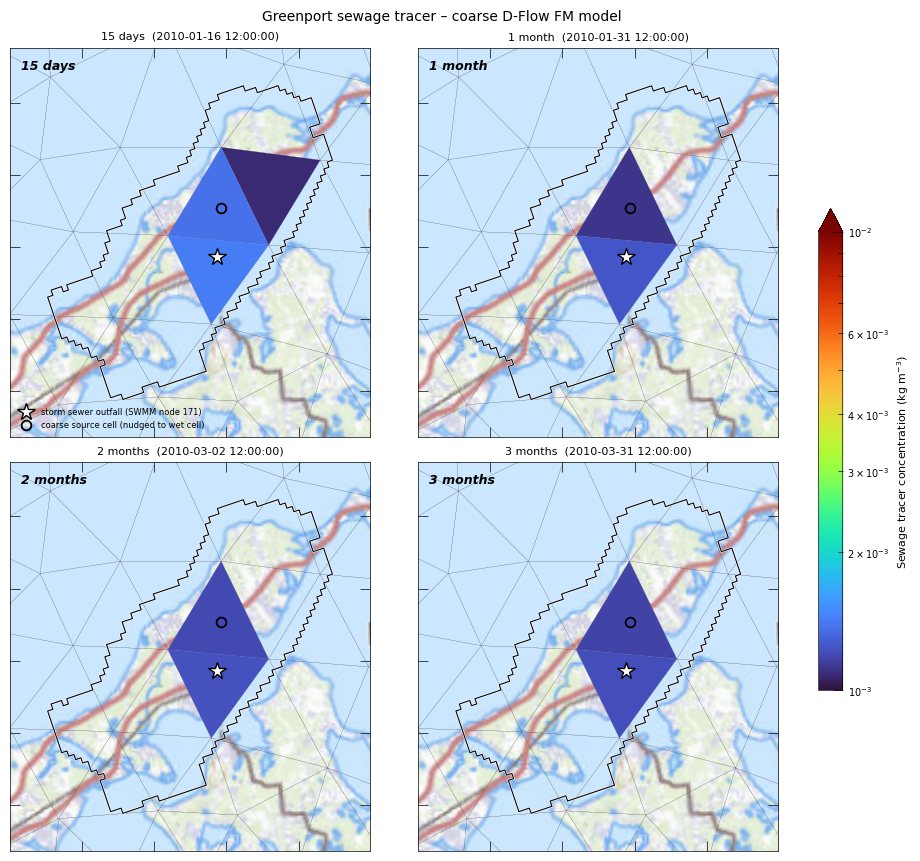

In [10]:
with styles.USGSMap():
    fig, axs = plt.subplots(2, 2, figsize=figsize, layout="constrained")
    axs = axs.ravel()

    pc = None
    for ax, idx, lbl in zip(axs, time_index, panel_labels):
        # grid outline
        grid_gdf.plot(ax=ax, fc="none", ec="0.35", lw=0.12, zorder=2)
        # tracer field (masked so only the plume is coloured)
        p = ds[tracer_var].isel(time=idx).ugrid.plot(
            ax=ax, cmap=cmap, norm=norm, lw=0.0,
            add_colorbar=False, zorder=3,
        )
        p.set_array(masked_tracer(idx))
        pc = p
        # Greenport MODFLOW model area
        gp_outline.boundary.plot(ax=ax, ec="white", lw=1.6, zorder=4)
        gp_outline.boundary.plot(ax=ax, ec="black", lw=0.8, zorder=5)
        # storm sewer outfall (node 171) and the nudged coarse source cell
        ax.plot(src_xy[0], src_xy[1], marker="*", ms=13, mfc="white",
                mec="black", mew=1.0, ls="none", zorder=7, label=src_label)
        ax.plot(coarse_src_xy[0], coarse_src_xy[1], marker="o", ms=7, mfc="none",
                mec="black", mew=1.3, ls="none", zorder=6, label=coarse_src_label)
        # basemap
        cx.add_basemap(ax, crs=dflow_crs, **basemap_kwds)

        ax.set_xlim(extent_x)
        ax.set_ylim(extent_y)
        ax.set_xlabel(None); ax.set_ylabel(None)
        ax.set_xticklabels([]); ax.set_yticklabels([])
        title = set_title_string(times[idx])
        ax.set_title(f"{lbl}  ({title})", size=8)
        styles.add_text(ax, text=lbl, x=0.03, y=0.97, bold=True, va="top", ha="left")

    axs[0].legend(loc="lower left", fontsize=6, framealpha=0.85, markerscale=1.0)

    cb = fig.colorbar(pc, ax=axs, shrink=0.6, extend="max", location="right")
    cb.set_label("Sewage tracer concentration (kg m$^{-3}$)", size=8)
    fig.suptitle("Greenport sewage tracer \u2013 coarse D-Flow FM model", fontsize=10)

    fig.savefig(fig_ws / f"greenport_tracer_4panel{fig_ext}", dpi=300, transparent=transparent)

In [11]:
ds.close()